In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('C:\\Users\\HP\\Documents\\finrisk\\data\\raw\\loan.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_61004\4246010962.py:1: DtypeWarning: Columns (0: desc, 1: next_pymnt_d, 2: verification_status_joint, 3: sec_app_earliest_cr_line, 4: hardship_type, 5: hardship_reason, 6: hardship_status, 7: hardship_start_date, 8: hardship_end_date, 9: payment_plan_start_date, 10: hardship_loan_status, 11: debt_settlement_flag_date, 12: settlement_status, 13: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\\Users\\HP\\Documents\\finrisk\\data\\raw\\loan.csv')


In [16]:
# Check missing values for top columns
missing_pct = df.isnull().mean() * 100
print("Top Columns with Missing Values (in %):")
missing_pct[missing_pct > 0].sort_values(ascending=False).head(15)

Top Columns with Missing Values (in %):


id                                            100.000000
member_id                                     100.000000
url                                           100.000000
orig_projected_additional_accrued_interest     99.627278
hardship_loan_status                           99.530537
hardship_start_date                            99.530537
hardship_end_date                              99.530537
hardship_status                                99.530537
hardship_type                                  99.530537
hardship_amount                                99.530537
hardship_dpd                                   99.530537
hardship_length                                99.530537
payment_plan_start_date                        99.530537
hardship_last_payment_amount                   99.530537
hardship_payoff_balance_amount                 99.530537
dtype: float64

In [17]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    "missing_percentage",
    ascending=False
)

missing.head(20)

,missing_count,missing_percentage
id,2260668,100.000000
member_id,2260668,100.000000
url,2260668,100.000000
orig_projected_additional_accrued_interest,2252242,99.627278
hardship_amount,2250055,99.530537
hardship_dpd,2250055,99.530537
hardship_loan_status,2250055,99.530537
deferral_term,2250055,99.530537
hardship_end_date,2250055,99.530537
hardship_status,2250055,99.530537


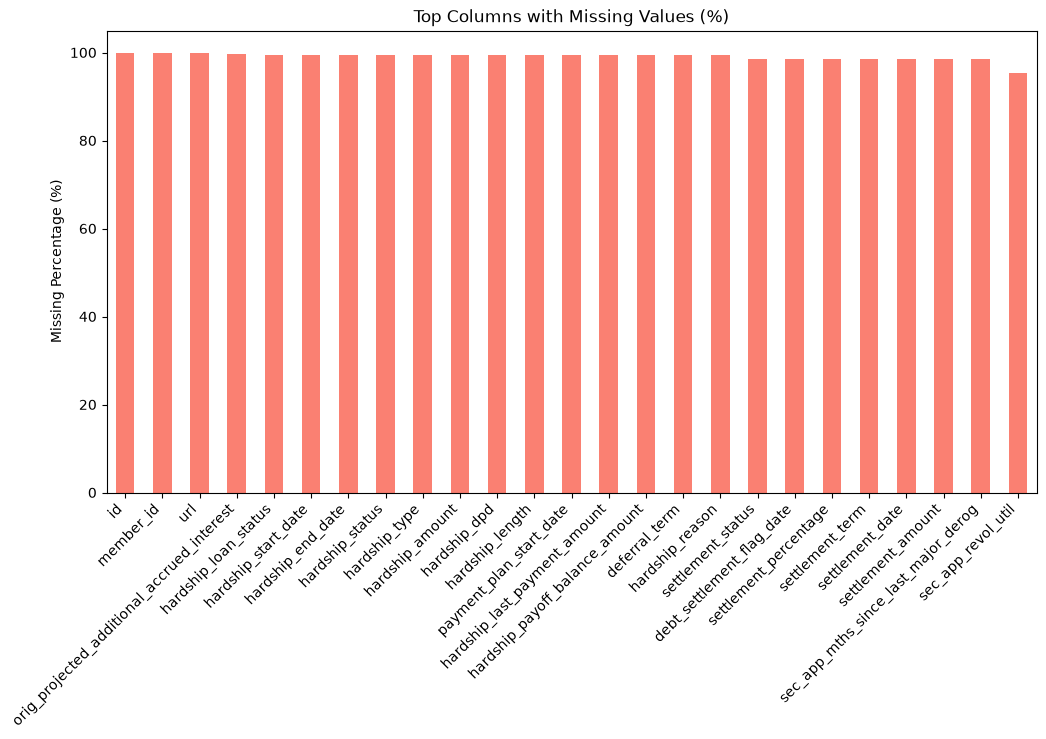

In [18]:

missing_pct = df.isnull().mean() * 100
missing_cols = missing_pct[missing_pct > 0].sort_values(ascending=False)


plt.figure(figsize=(12, 6))
missing_cols.head(25).plot(kind='bar', color='salmon')
plt.title("Top Columns with Missing Values (%)")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45, ha='right')
plt.show()

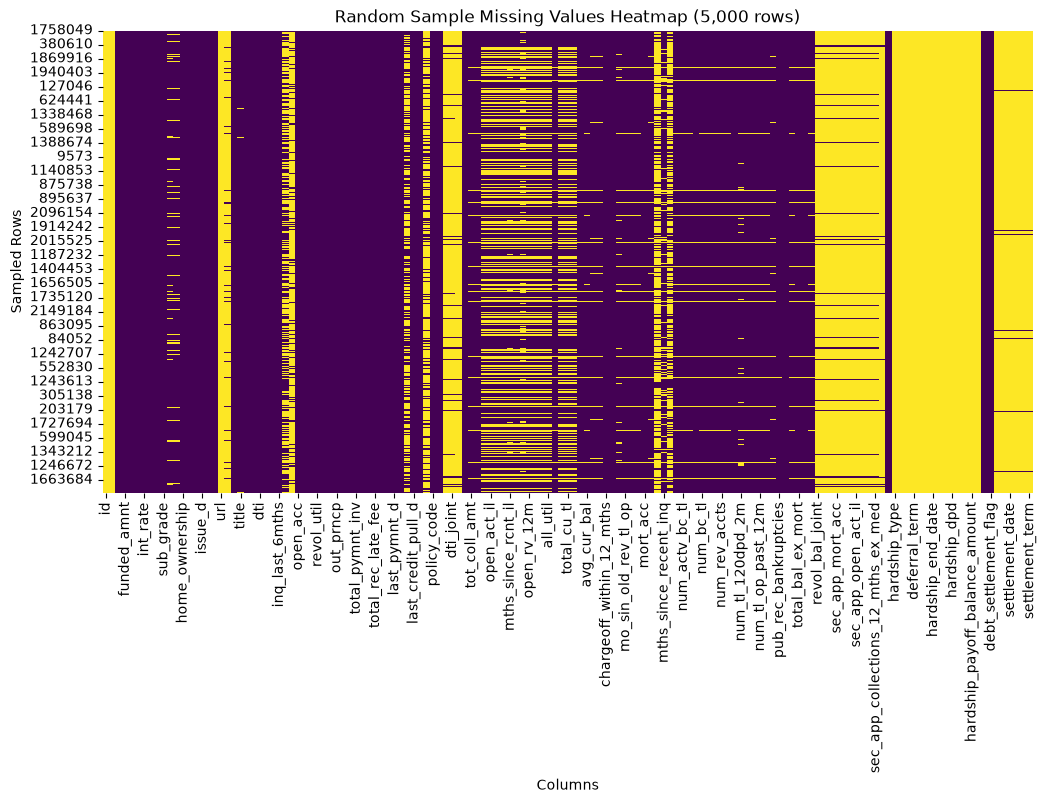

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Take a random sample of 5,000 rows to prevent a MemoryError
plt.figure(figsize=(12, 6))
sns.heatmap(df.sample(5000, random_state=42).isnull(), cbar=False, cmap='viridis')
plt.title("Random Sample Missing Values Heatmap (5,000 rows)")
plt.xlabel("Columns")
plt.ylabel("Sampled Rows")
plt.show()

In [20]:
df.shape

(2260668, 145)

In [21]:
# 1. Remove Data Leakage Columns
leakage_cols = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 
    'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 
    'last_credit_pull_d', 'hardship_flag', 'hardship_type', 'hardship_reason', 
    'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 
    'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 
    'hardship_loan_status', 'orig_projected_additional_accrued_interest', 
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term'
]
df = df.drop(columns=[col for col in leakage_cols if col in df.columns], errors='ignore')

# 2. Fix the bug: Drop completely empty ID columns first
df = df.drop(columns=['id', 'member_id', 'url'], errors='ignore')

# Now drop actual duplicate rows based on all remaining valid data
df = df.drop_duplicates()

# 3. Audit and Remove Columns with >50% Missing Data
missing_percent = (df.isnull().sum() / len(df)) * 100
cols_to_drop = missing_percent[missing_percent > 50].index

df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Shape of dataframe after Corrected Phase A: {df.shape}")
print("\nRemaining columns with missing values:")
remaining_missing = (df.isnull().sum() / len(df)) * 100
print(remaining_missing[remaining_missing > 0].sort_values(ascending=False).head(15))

Shape of dataframe after Corrected Phase A: (2260668, 87)

Remaining columns with missing values:
il_util                  47.280273
mths_since_rcnt_il       40.250227
all_util                 38.322655
total_cu_tl              38.313012
inq_last_12m             38.313012
open_acc_6m              38.313012
open_rv_24m              38.312968
open_il_12m              38.312968
open_il_24m              38.312968
total_bal_il             38.312968
open_act_il              38.312968
inq_fi                   38.312968
open_rv_12m              38.312968
max_bal_bc               38.312968
mths_since_recent_inq    13.068482
dtype: float64


Target Transformation

In [22]:
valid_statuses = ['Fully Paid', 'Charged Off', 'Default']
df = df[df['loan_status'].isin(valid_statuses)].copy()
target_mapping = {'Fully Paid': 0, 'Charged Off': 1, 'Default': 1}
df['target'] = df['loan_status'].map(target_mapping)
df = df.drop(columns=['loan_status'])

Imputation

In [23]:
missing_cols = df.columns[df.isnull().sum() > 0]

for col in missing_cols:
    # Check if the column is numerical (float or int)
    if df[col].dtype in ['int64', 'float64']:
        # Apply Rule 3: Fill numeric data with the Median
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
    else:
        # Apply Rule 4: Fill text/categorical data with "Unknown"
        df[col] = df[col].fillna("Unknown")

Verification

In [24]:
print(f"Shape after Phase Verification and Imputation: {df.shape}")
print("\nTarget Distribution (0 = Paid, 1 = Default):")
print(df['target'].value_counts(normalize=True) * 100) # Shows percentage
print(f"\nTotal missing values remaining in entire dataset: {df.isnull().sum().sum()}")

Shape after Phase Verification and Imputation: (1303638, 87)

Target Distribution (0 = Paid, 1 = Default):
target
0    79.926483
1    20.073517
Name: proportion, dtype: float64

Total missing values remaining in entire dataset: 0


Date Handling

In [25]:
if 'earliest_cr_line' in df.columns and 'issue_d' in df.columns:
    df['earliest_cr_line_dt'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
    df['issue_d_dt'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
    
    # Calculate exact months of credit history before the loan was issued
    df['mths_credit_history'] = (
        (df['issue_d_dt'].dt.year - df['earliest_cr_line_dt'].dt.year) * 12 + 
        (df['issue_d_dt'].dt.month - df['earliest_cr_line_dt'].dt.month)
    ).fillna(df['earliest_cr_line_dt'].dt.month.median()) # Fill any weird parse errors
    
    # Drop the original date columns since models can't read them
    df = df.drop(columns=['earliest_cr_line', 'earliest_cr_line_dt', 'issue_d', 'issue_d_dt'])

Outlier Treatment (Winsorization)

In [26]:
if 'annual_inc' in df.columns:
    p99_income = df['annual_inc'].quantile(0.99)
    df['annual_inc'] = np.where(df['annual_inc'] > p99_income, p99_income, df['annual_inc'])
    print(f"Capped Annual Income at the 99th percentile: ${p99_income:,.2f}")

print(f"\nShape after Dates & Outliers: {df.shape}")

Capped Annual Income at the 99th percentile: $250,000.00

Shape after Dates & Outliers: (1303638, 86)


Drop High-Cardinality Text

In [27]:
high_cardinality_cols = ['emp_title', 'title', 'desc', 'zip_code']
df = df.drop(columns=[col for col in high_cardinality_cols if col in df.columns], errors='ignore')

One-Hot Encoding

In [28]:
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

C:\Users\HP\AppData\Local\Temp\ipykernel_61004\1317456663.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Final Verification

In [29]:
print(f"Final dataset shape ready for Machine Learning: {df.shape}")
print(f"Data types present: {df.dtypes.unique()}")
df.sample(5)

Final dataset shape ready for Machine Learning: (1303638, 196)
Data types present: [dtype('int64') dtype('float64') dtype('int32')]


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,...,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY,initial_list_status_w,application_type_Joint App,disbursement_method_DirectPay
1190859,16000,16000,16000.0,18.25,408.48,55000.0,6.07,0.0,1.0,8.0,...,0,0,0,1,0,0,0,1,0,0
1067626,20000,20000,20000.0,13.99,465.27,197000.0,11.82,0.0,0.0,9.0,...,0,0,0,0,0,0,0,1,0,0
1676010,35000,35000,35000.0,18.25,893.54,140000.0,6.02,0.0,0.0,10.0,...,0,0,0,0,0,0,0,0,0,0
1026425,28000,28000,28000.0,7.26,867.90,125000.0,9.12,0.0,0.0,6.0,...,0,0,0,0,0,0,0,1,0,0
1872716,12500,12500,12500.0,10.49,406.23,100000.0,15.14,2.0,1.0,20.0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
df.columns.tolist()

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'collections_12_mths_ex_med',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_inq',
 'num_accts_ever_120_pd',
 'num_actv_bc_tl',
 'num_actv_rev_tl',
 'num_bc_sats',
 'num_bc_tl',
 'num_il_tl',
 'num_op_rev_tl',
 'num_rev_accts',
 'num_rev_tl_bal_gt_0',
 'num_sats',

In [31]:
df.isnull().sum().to_list

<bound method IndexOpsMixin.tolist of loan_amnt                        0
funded_amnt                      0
funded_amnt_inv                  0
int_rate                         0
installment                      0
                                ..
addr_state_WV                    0
addr_state_WY                    0
initial_list_status_w            0
application_type_Joint App       0
disbursement_method_DirectPay    0
Length: 196, dtype: int64>

1.Identify any column containing leakage keywords
2.Create a list of all columns that match the banned keywords
3.Drop them from the dataframe

In [33]:
leakage_keywords = [
    'pymnt', 'prncp', 'rec_int', 'late_fee', 'recoveries', 
    'collection_recovery_fee', 'hardship', 'settlement', 'last_credit_pull'
]

leakage_cols_to_drop = [col for col in df.columns if any(keyword in col for keyword in leakage_keywords)]


df = df.drop(columns=leakage_cols_to_drop)

print(f"Final clean shape after plugging the data leak: {df.shape}")

Final clean shape after plugging the data leak: (1303638, 196)


In [34]:
df.to_csv('cleaned_loans.csv', index=False)
print("Cleaned data successfully saved as 'cleaned_loans.csv'")

Cleaned data successfully saved as 'cleaned_loans.csv'
